In [ ]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from src.configs.defaults import RANDOM_SEED, IMAGE_ROOT, TEST_IMAGE_ROOT, EXCLUDE_IMAGE_DIRS, LABEL_ROOT, EXCLUDE_LABEL_DIRS, CLASSES, CLASS2IND, IND2CLASS, SAVED_DIR, PALETTE
from src.utils.set_seed import set_seed
from src.data.test_data import XRayInferenceDataset
from src.data.utils import split_train_val, is_excluded, encode_mask_to_rle, decode_rle_to_mask
from src.data.transforms import get_valid_transform, get_tta_transform
from src.metrics.dice import dice_coef

import json
import numpy as np
import pandas as pd
import cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

ImportError: cannot import name 'EXCLUDE_IMAGE_DIRS' from 'src.configs.defaults' (/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/src/configs/defaults.py)

In [2]:
class XRayValidDataset(Dataset):         # valid 시각화를 위한 dataset
    def __init__(self, tta=False):
        
        # 이미지 및 라벨 불러오기
        pngs = {
            os.path.relpath(os.path.join(root, fname), start=IMAGE_ROOT)
            for root, _dirs, files in os.walk(IMAGE_ROOT)
            if not is_excluded(root, IMAGE_ROOT, EXCLUDE_IMAGE_DIRS)
            for fname in files
            if os.path.splitext(fname)[1].lower() == ".png"
        }
        jsons = {
            os.path.relpath(os.path.join(root, fname), start=LABEL_ROOT)
            for root, _dirs, files in os.walk(LABEL_ROOT)
            if not is_excluded(root, IMAGE_ROOT, EXCLUDE_LABEL_DIRS)
            for fname in files
            if os.path.splitext(fname)[1].lower() == ".json"
        }
        
        # 모든 .png 파일에 대해 .json 파일이 존재하는지 확인
        jsons_fn_prefix = {os.path.splitext(fname)[0] for fname in jsons}
        pngs_fn_prefix = {os.path.splitext(fname)[0] for fname in pngs}

        assert len(jsons_fn_prefix - pngs_fn_prefix) == 0
        assert len(pngs_fn_prefix - jsons_fn_prefix) == 0
        
        pngs = sorted(pngs)
        jsons = sorted(jsons)
        
        _filenames = np.array(pngs)
        _labelnames = np.array(jsons)
        
        filenames, labelnames = split_train_val(_filenames, _labelnames, n_splits=5, is_train=False)
        
        self.filenames = filenames
        self.labelnames = labelnames
        self.is_train = False
        self.transforms = get_valid_transform()
        self.tta_transforms = get_tta_transform() if tta else None
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, item):
        image_name = self.filenames[item]
        image_path = os.path.join(IMAGE_ROOT, image_name)
        
        image = cv2.imread(image_path)
        image = image / 255.
        
        label_name = self.labelnames[item]
        label_path = os.path.join(LABEL_ROOT, label_name)
        
        # (H, W, NC) 모양의 label을 생성합니다.
        label_shape = tuple(image.shape[:2]) + (len(CLASSES), )
        label = np.zeros(label_shape, dtype=np.uint8)
        
        # label 파일을 읽습니다.
        with open(label_path, "r") as f:
            annotations = json.load(f)
        annotations = annotations["annotations"]
        
        # 클래스 별로 처리합니다.
        for ann in annotations:
            c = ann["label"]
            class_ind = CLASS2IND[c]
            points = np.array(ann["points"])
            
            # polygon 포맷을 dense한 mask 포맷으로 바꿉니다.
            class_label = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(class_label, [points], 1)
            label[..., class_ind] = class_label
        
        if self.tta_transforms is not None:
            tta_result = self.tta_transforms(image=image)
            tta_image = tta_result["image"]

            image = np.stack([image, tta_image], axis=0)
            label = np.stack([label, label], axis=0)
        
        if self.tta_transforms is None:
            image = image.transpose(2, 0, 1)
            label = label.transpose(2, 0, 1)
        else:
            image = image.transpose(0, 3, 1, 2)
            label = label.transpose(0, 3, 1, 2)
        
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).float()
            
        return image, image_name, label

In [ ]:
def validation_dice_per_class(model, data_loader, thresholds=[0.5], tta=False, n_classes=len(CLASSES)):
    model.eval()
    model = model.cuda()
    
    dices_per_class_per_thr = {thr: [] for thr in thresholds}

    with torch.no_grad():
        for images, _, masks in tqdm(data_loader):
            images, masks = images.cuda(), masks.cuda()

            if tta:
                b, n_tta, C, H, W = images.shape
                outputs_tta = []
                for t in range(n_tta):
                    out = model(images[:, t])
                    outputs_tta.append(out)
                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = outputs.mean(dim=1)
                masks = masks[:, 0]
            else:
                outputs = model(images)

            probs = torch.sigmoid(outputs)

            for thr in thresholds:
                preds = (probs > thr).float()
                dice_batch = dice_coef(masks, preds) 
                dices_per_class_per_thr[thr].append(dice_batch)

    dice_mean_results = {}
    dice_per_class_results = {}
    for thr in thresholds:
        dice_class_all = torch.cat(dices_per_class_per_thr[thr], dim=0) 
        dice_per_class_results[thr] = dice_class_all.mean(dim=0).tolist()
        dice_mean_results[thr] = dice_class_all.mean().item()

    return dice_mean_results, dice_per_class_results

In [12]:
set_seed(RANDOM_SEED)
    
save_file_name = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/outputs/checkpoints/upernet_2048_tta_best.pt"
model = torch.load(os.path.join(save_file_name), weights_only=False)

valid_dataset = XRayValidDataset(tta=True)

valid_loader = DataLoader(
    dataset=valid_dataset, 
    batch_size=2,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

thresholds = torch.linspace(0.1, 0.9, 17).tolist()

dice_mean_results, dice_per_class_results = validation_dice_per_class(model, valid_loader, thresholds=thresholds, tta=True)

  0%|          | 0/80 [00:00<?, ?it/s]

5
torch.Size([2, 2, 3, 2048, 2048])


UnboundLocalError: local variable 'outputs' referenced before assignment

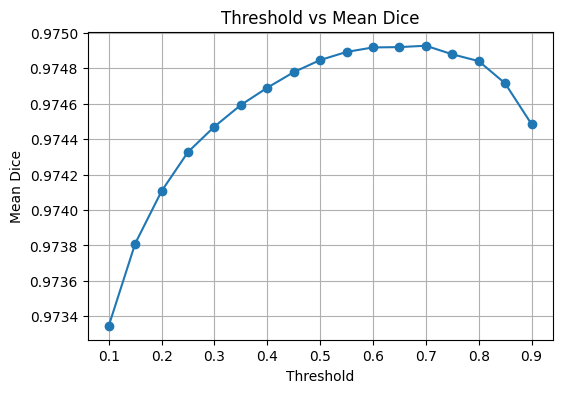

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(thresholds.cpu(), dice_mean_results, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Mean Dice")
plt.title("Threshold vs Mean Dice")
plt.grid(True)
plt.show()

In [ ]:
best_thr_per_class = {}

for c in range(dice_per_class_results.shape[1]):
    best_idx = torch.argmax(dice_per_class_results[:, c])
    best_thr = thresholds[best_idx].item()
    best_dice = dice_per_class_results[best_idx, c].item()
    
    best_thr_per_class[IND2CLASS[c]] = {
        "best_thr": best_thr,
        "best_dice": best_dice
    }

for class_name in best_thr_per_class:
    print(f"class: {class_name} | best threshold: {best_thr_per_class[class_name]['best_thr']}, best dice: {best_thr_per_class[class_name]['best_dice']}")

class: finger-1 | best threshold: 0.8499999642372131, best dice: 0.968876302242279
class: finger-2 | best threshold: 0.8499999642372131, best dice: 0.984309196472168
class: finger-3 | best threshold: 0.6499999761581421, best dice: 0.9882184863090515
class: finger-4 | best threshold: 0.8999999761581421, best dice: 0.9772732853889465
class: finger-5 | best threshold: 0.6499999761581421, best dice: 0.9775829315185547
class: finger-6 | best threshold: 0.5, best dice: 0.9881807565689087
class: finger-7 | best threshold: 0.3999999761581421, best dice: 0.9865778088569641
class: finger-8 | best threshold: 0.699999988079071, best dice: 0.9785448908805847
class: finger-9 | best threshold: 0.699999988079071, best dice: 0.9806435704231262
class: finger-10 | best threshold: 0.699999988079071, best dice: 0.9884433150291443
class: finger-11 | best threshold: 0.8999999761581421, best dice: 0.981115460395813
class: finger-12 | best threshold: 0.6499999761581421, best dice: 0.9798039793968201
class: fin

In [ ]:
mean_dice = np.mean([v['best_dice'] for v in best_thr_per_class.values()])

print(f"Validation Dice: {mean_dice:.4f}")

Validation Dice: 0.9751


In [ ]:
def test(model, data_loader, class_thr, tta=False):
    model = model.cuda()
    model.eval()

    rles = []
    filename_and_class = []
    with torch.no_grad():
        for step, (images, image_names) in tqdm(enumerate(data_loader), total=len(data_loader)):
            images = images.cuda()
            
            if not tta: 
                outputs = model(images)
            else:
                if images.dim() == 4 and images.size(0) % 2 == 0:  # TTA 2개 가정
                    batch_size = images.size(0) // 2
                    images = images.view(batch_size, 2, images.size(1), images.size(2), images.size(3))

                batch_size, n_tta, C, H, W = images.shape            
                outputs_tta = []
                
                for t in range(n_tta):
                    img = images[:, t]
                    output = model(img)
                    outputs_tta.append(output)

                outputs = torch.stack(outputs_tta, dim=1)
                outputs[:, 1] = torch.flip(outputs[:, 1], dims=[-1])
                outputs = torch.mean(outputs, dim=1)
            
            outputs = F.interpolate(outputs, size=(2048, 2048), mode="bilinear")
            outputs = torch.sigmoid(outputs)
            
            class_thr = class_thr.to(outputs.device)

            outputs = (outputs > class_thr)
            outputs = outputs.detach().cpu().numpy()
            
            for output, image_name in zip(outputs, image_names):
                for c, segm in enumerate(output):
                    rle = encode_mask_to_rle(segm)
                    rles.append(rle)
                    filename_and_class.append(f"{IND2CLASS[c]}_{image_name}")
                    
    return rles, filename_and_class

In [18]:
set_seed(RANDOM_SEED)
    
tta = True
save_file_name = 'upernet_2048_tta_best.pt'
model = torch.load(os.path.join(SAVED_DIR, save_file_name), weights_only=False)

test_dataset = XRayInferenceDataset(tta)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=2,
    shuffle=False,
    num_workers=2,
    drop_last=False
)

class_thr = [
    best_thr_per_class[IND2CLASS[c]]['best_thr']
    for c in range(len(IND2CLASS))
]

class_thr = torch.tensor(class_thr).view(1, -1, 1, 1)
    
rles, filename_and_class = test(model, test_loader, class_thr, tta=tta)
    
classes, filename = zip(*[x.split("_") for x in filename_and_class])
image_name = [os.path.basename(f) for f in filename]
df = pd.DataFrame({
    "image_name": image_name,
    "class": classes,
    "rle": rles,
})
df.to_csv("/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/outputs/output_threshold.csv", index=False)

  0%|          | 0/144 [00:00<?, ?it/s]

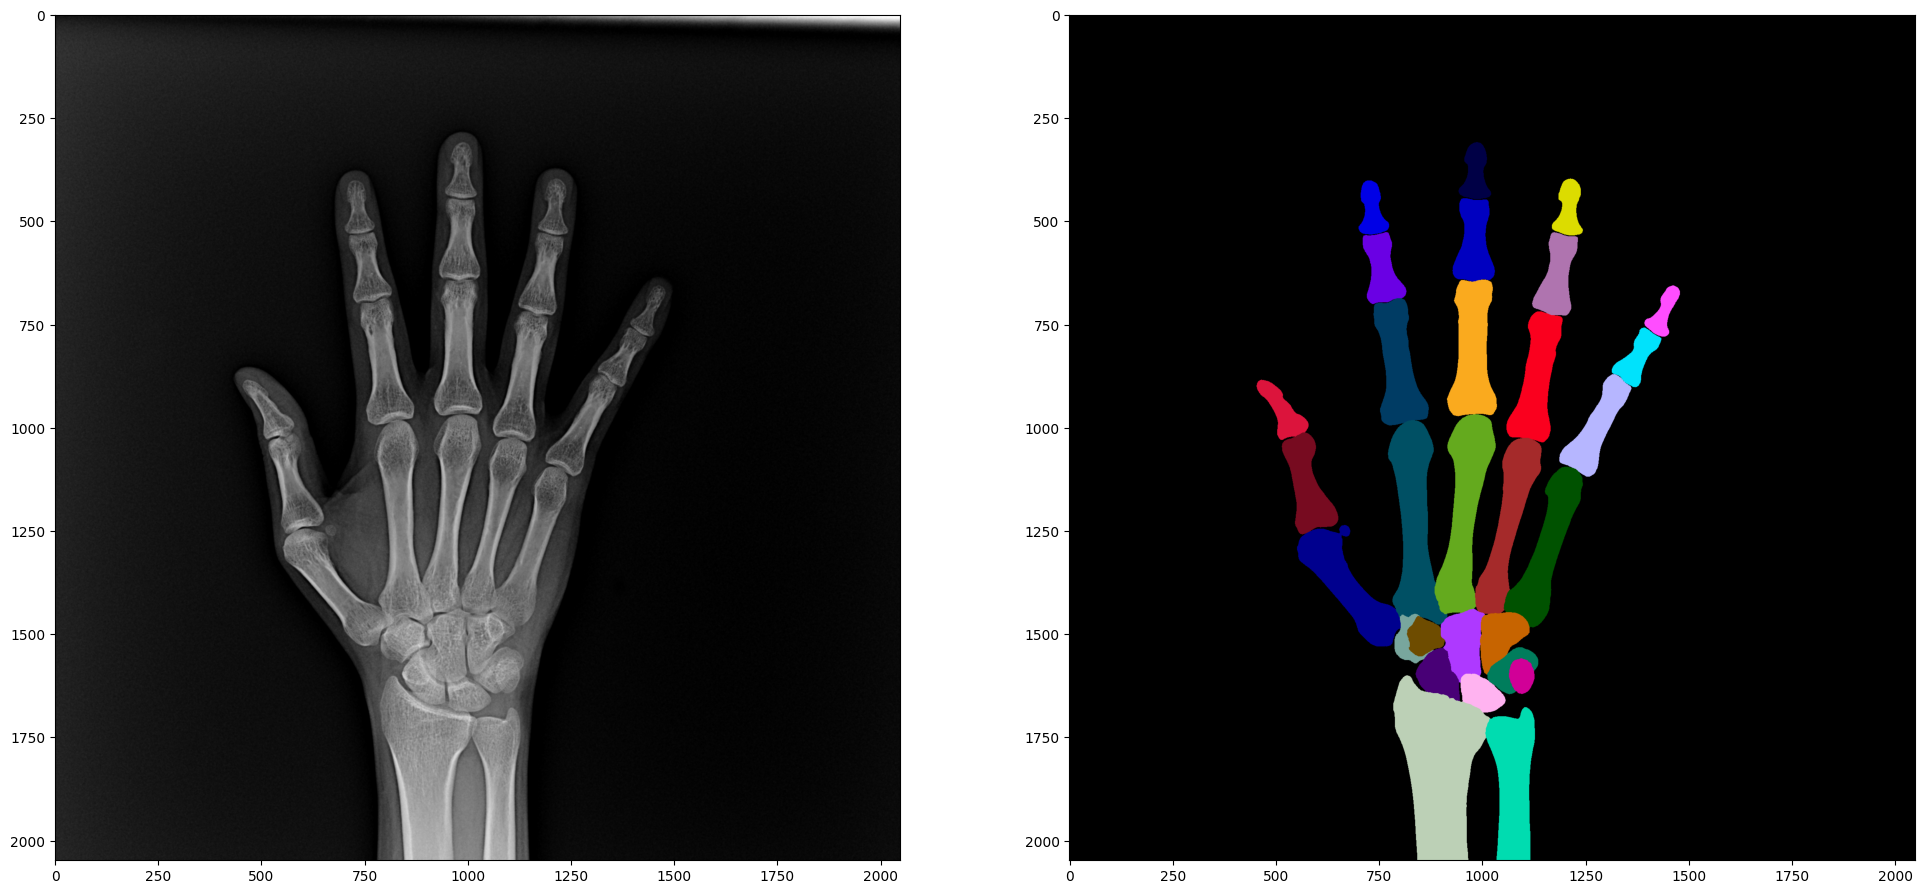

In [21]:
image = cv2.imread(os.path.join(TEST_IMAGE_ROOT, filename_and_class[0].split("_")[1]))

preds = []
for rle in rles[:len(CLASSES)]:
    pred = decode_rle_to_mask(rle, height=2048, width=2048)
    preds.append(pred)

preds = np.stack(preds, 0)

def label2rgb(label):
    image_size = label.shape[1:] + (3, )
    image = np.zeros(image_size, dtype=np.uint8)
    
    for i, class_label in enumerate(label):
        image[class_label == 1] = PALETTE[i]
        
    return image

fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(image)    # remove channel dimension
ax[1].imshow(label2rgb(preds))

plt.show()
